In [58]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Config
%matplotlib inline
sns.set_theme(style="whitegrid", palette="pastel")

In [59]:
# Datasets
datasets = [
    'dataset1/',
    'dataset2/',
    'dataset3/',
    'dataset4/',
    'dataset5/'
]

folders = [
    'EarliestSetting8tele',
    'Random8tele',
    'ShortestSlew8tele',
    'tsp8',
    'tspcRoundRobin8',
    'tspcLoadBal8',
    'tspcKmean8',
    'tspcRightAsc8',
    'tspcKMeanEarlySetting8'
]

folder_name_map = {
    "EarliestSetting8tele": "Earliest Setting",
    "Random8tele": "Random",
    "ShortestSlew8tele": "Shortest Slew",
    "tsp8": "MTSP Gurobi",
    "tspcRoundRobin8": "MTSP Concorde (RRP)",
    "tspcLoadBal8": "MTSP Concorde (LBP)",
    "tspcKmean8": "MTSP Concorde (KmP)",
    "tspcRightAsc8": "MTSP Concorde (RAP)",
    "tspcKMeanEarlySetting8": "MTSP Concorde (KmP + ES)"
}

dataset_dfs = {}

for dataset in datasets:
    dataset_name = os.path.basename(os.path.normpath(dataset)) or dataset.strip('/')

    stats_list = []

    for folder in folders:
        folder_path = os.path.join(dataset, folder)
        csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
    
        raw_folder_name = os.path.basename(os.path.normpath(folder))
        folder_name = folder_name_map.get(raw_folder_name, raw_folder_name)
    
        print(f"Processing {dataset_name} - {folder_name} with {len(csv_files)} files.")
    
        for file in csv_files:
            try:
                df = pd.read_csv(file, header=4)
                df.columns = df.columns.str.strip()
    
                # Compute total duration: sum Duration over all telescopes
                df['No'] = pd.to_numeric(df['No'], errors='coerce')
                total_duration = df['No'].sum()
    
                df['Wait time'] = pd.to_numeric(df['Wait time'], errors='coerce')
                total_observation = df['Wait time'].sum()
    
                stats_list.append({
                    'File': os.path.basename(file),
                    'Folder': folder_name,
                    'Total Duration': total_duration/8,
                    'Observation Time': total_observation/8
                })
    
            except Exception as e:
                print(f"Error processing {file}: {e}")

    
    dataset_df = pd.DataFrame(stats_list)
    dataset_dfs[dataset_name] = dataset_df



Processing dataset1 - Earliest Setting with 10 files.
Processing dataset1 - Random with 10 files.
Processing dataset1 - Shortest Slew with 10 files.
Processing dataset1 - MTSP Gurobi with 10 files.
Processing dataset1 - MTSP Concorde (RRP) with 10 files.
Processing dataset1 - MTSP Concorde (LBP) with 10 files.
Processing dataset1 - MTSP Concorde (KmP) with 10 files.
Processing dataset1 - MTSP Concorde (RAP) with 10 files.
Processing dataset1 - MTSP Concorde (KmP + ES) with 10 files.
Processing dataset2 - Earliest Setting with 10 files.
Processing dataset2 - Random with 10 files.
Processing dataset2 - Shortest Slew with 10 files.
Processing dataset2 - MTSP Gurobi with 10 files.
Processing dataset2 - MTSP Concorde (RRP) with 10 files.
Processing dataset2 - MTSP Concorde (LBP) with 10 files.
Processing dataset2 - MTSP Concorde (KmP) with 10 files.
Processing dataset2 - MTSP Concorde (RAP) with 10 files.
Processing dataset2 - MTSP Concorde (KmP + ES) with 10 files.
Processing dataset3 - Ea

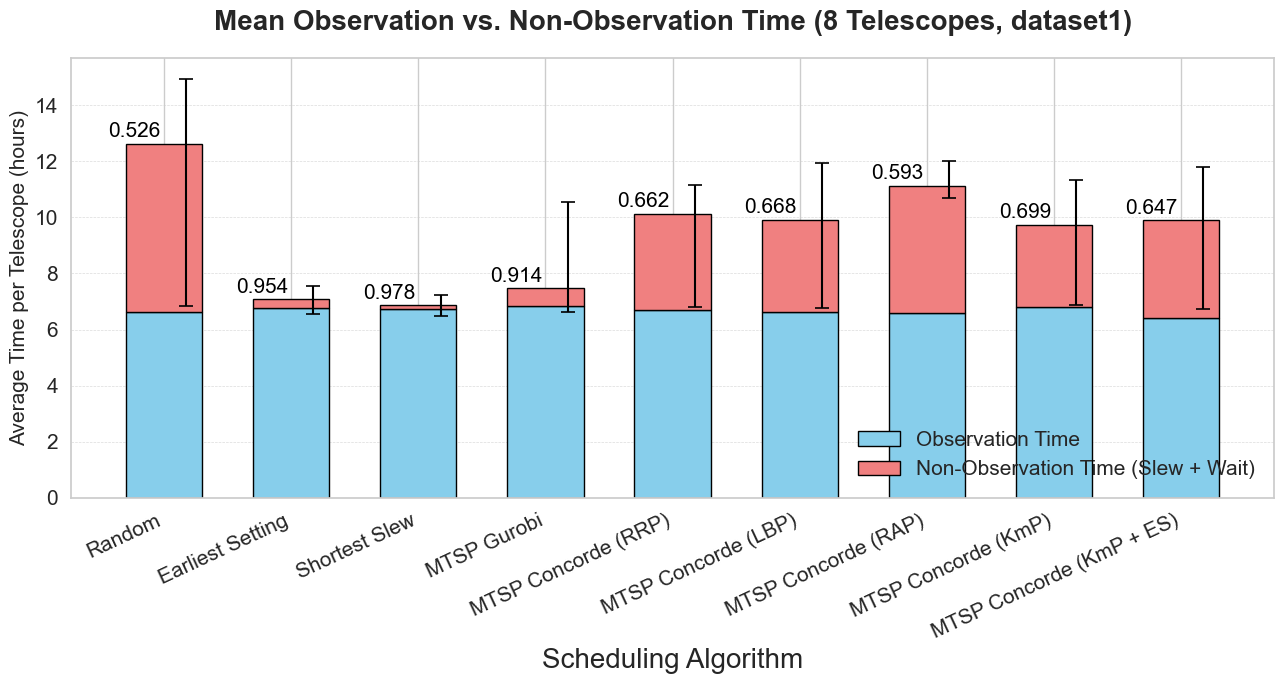

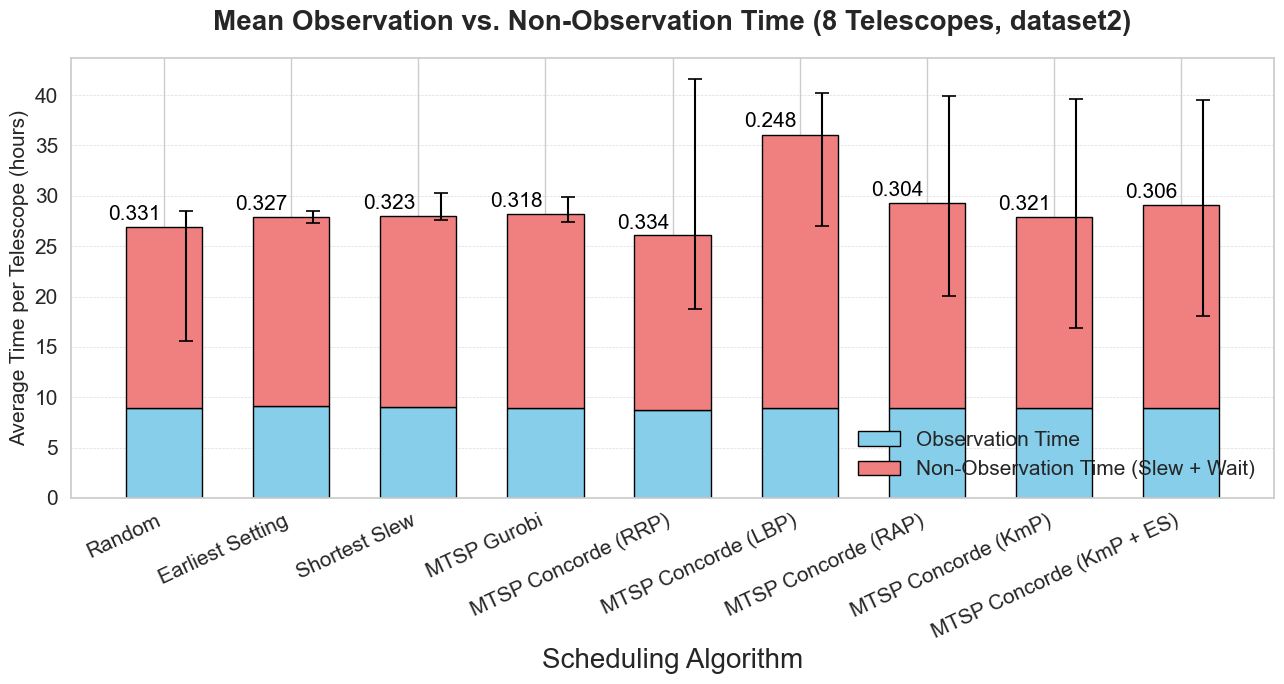

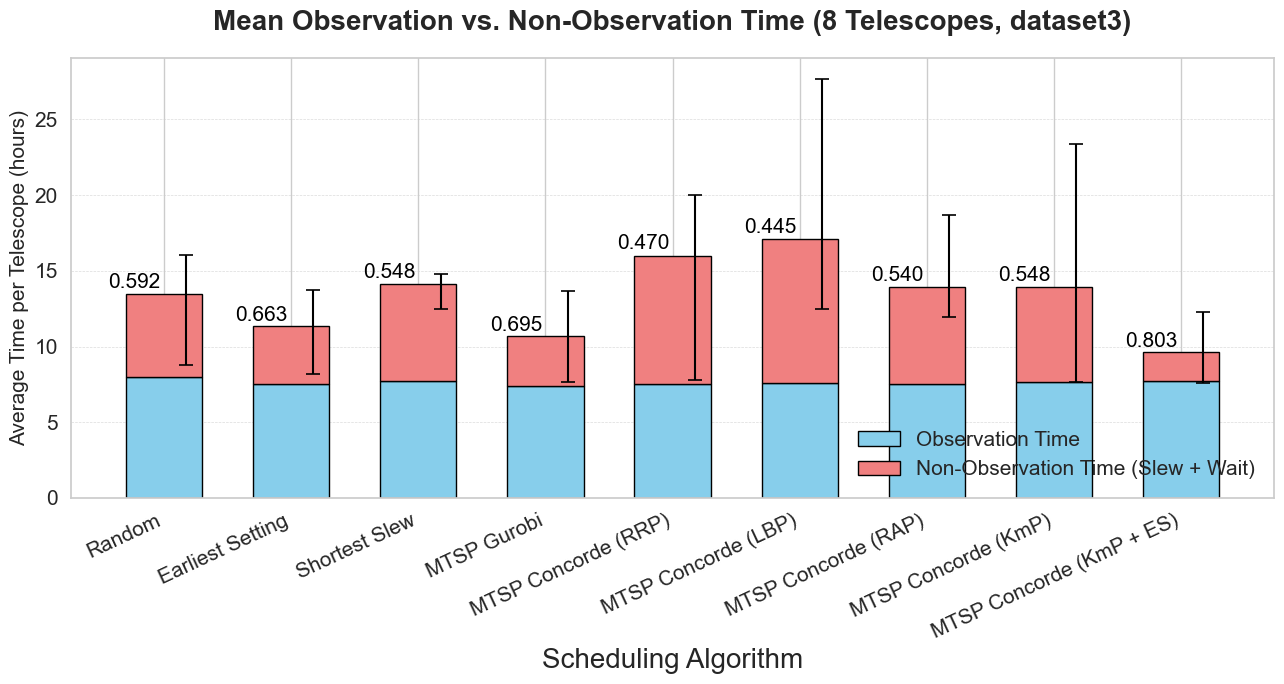

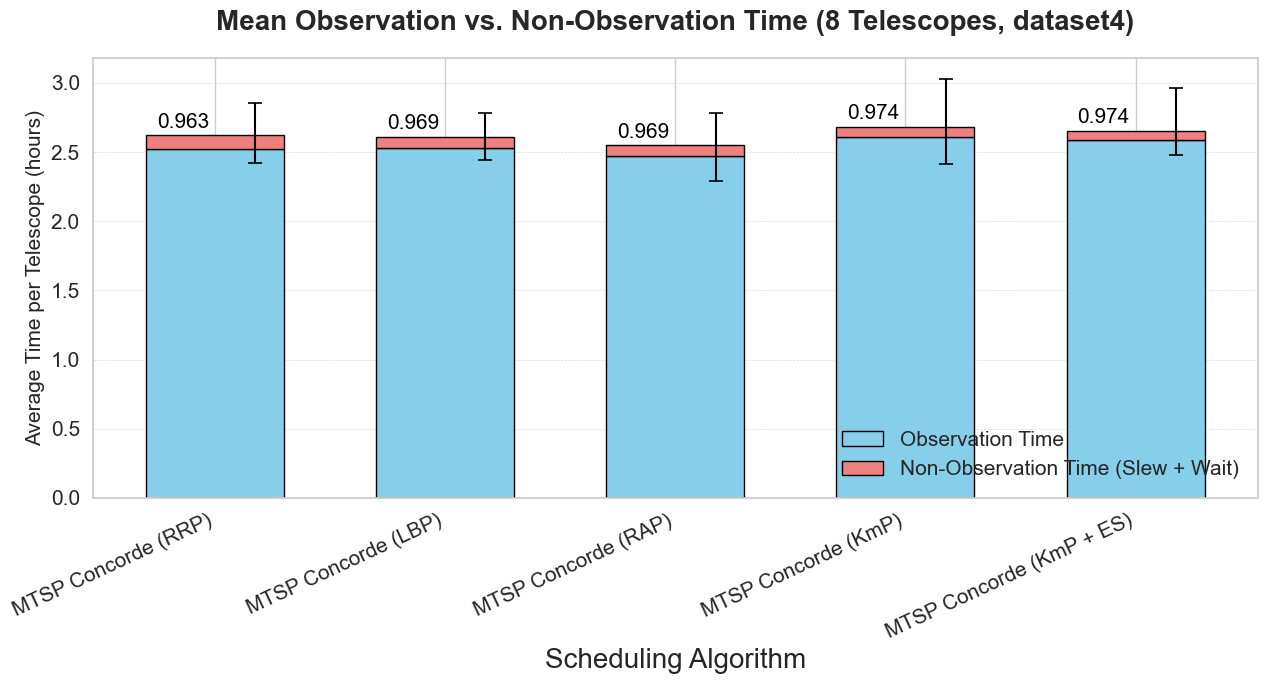

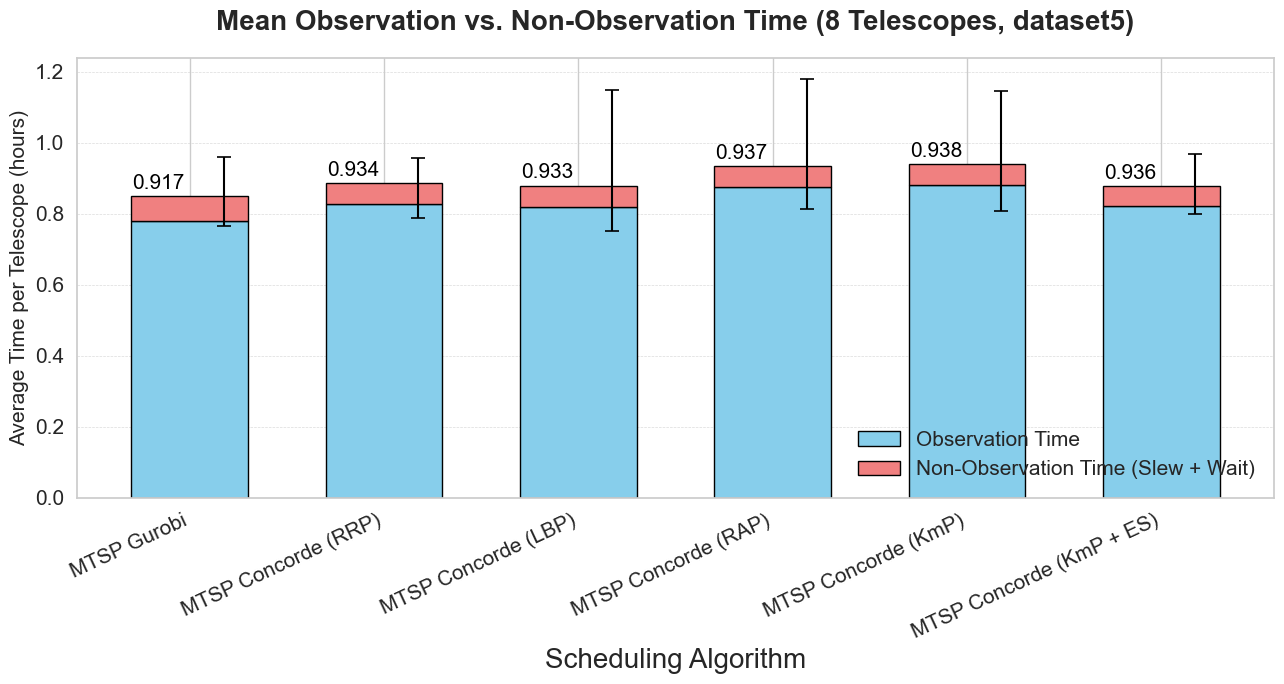

In [60]:
import matplotlib.pyplot as plt
import pandas as pd

# Replace this with your actual dataset_dfs dictionary
# dataset_dfs = { ... }

# Horizontal offset for spacing text/error bar left/right
offset = 0.025

for dataset_name, df in dataset_dfs.items():
    if df.empty:
        print(f"Skipping {dataset_name} because it has no data.")
        continue

    # Aggregate metrics: mean, min, max
    grouped = df.groupby('Folder').agg({
        'Total Duration': ['mean', 'min', 'max'],
        'Observation Time': ['mean', 'min', 'max']
    })

    # Flatten MultiIndex columns
    grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
    summary = grouped.reset_index()

    # Derived values
    summary['Non-Observation Time_mean'] = summary['Total Duration_mean'] - summary['Observation Time_mean']

    # Sort order
    desired_order = [
        "Random",
        "Earliest Setting",
        "Shortest Slew",
        "MTSP Gurobi",
        "MTSP Concorde (RRP)",
        "MTSP Concorde (LBP)",
        "MTSP Concorde (RAP)",
        "MTSP Concorde (KmP)",
        "MTSP Concorde (KmP + ES)"
    ]
    summary['Folder'] = pd.Categorical(summary['Folder'], categories=desired_order, ordered=True)
    summary = summary.sort_values('Folder')

    # X positions
    x = range(len(summary))

    # Plot
    plt.figure(figsize=(13, 7))
    bar_width = 0.6

    # Plot stacked bars
    plt.bar(x, summary['Observation Time_mean'], label='Observation Time', 
            color='skyblue', edgecolor='black', width=bar_width)
    plt.bar(x, summary['Non-Observation Time_mean'], bottom=summary['Observation Time_mean'],
            label='Non-Observation Time (Slew + Wait)', color='lightcoral', edgecolor='black', width=bar_width)

    # Error bars: Total Duration (min to max), slightly to the right of each bar
    total_err_lower = summary['Total Duration_mean'] - summary['Total Duration_min']
    total_err_upper = summary['Total Duration_max'] - summary['Total Duration_mean']

    plt.errorbar([xi + offset + 0.15 for xi in x], summary['Total Duration_mean'], 
                 yerr=[total_err_lower, total_err_upper],
                 fmt='none', ecolor='black', capsize=5, capthick=1.2)

    # Observation ratio (proportion), slightly to the left of top of each bar
    observation_ratio = summary['Observation Time_mean'] / summary['Total Duration_mean']
    for i, (obs, total) in enumerate(zip(summary['Observation Time_mean'], summary['Total Duration_mean'])):
        plt.text(i - offset, total + 0.01 * total,
                 f"{observation_ratio.iloc[i]:.3f}",
                 ha='right', va='bottom', fontsize=15, color='black')

    # Format
    plt.title(f"Mean Observation vs. Non-Observation Time (8 Telescopes, {dataset_name})", fontsize=20, weight='bold', pad=20)
    plt.ylabel("Average Time per Telescope (hours)", fontsize=15)
    plt.xlabel("Scheduling Algorithm", fontsize=20)
    plt.xticks(ticks=x, labels=summary['Folder'], rotation=25, ha='right', fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.legend(loc='lower right', fontsize=15)
    plt.tight_layout()   
    plt.show()


Processing dataset1 - 10 iterations with 10 files.
Processing dataset1 - 100 iterations with 10 files.
Processing dataset2 - 10 iterations with 10 files.
Processing dataset2 - 100 iterations with 10 files.
Processing dataset3 - 10 iterations with 10 files.
Processing dataset3 - 100 iterations with 10 files.
Processing dataset4 - 10 iterations with 10 files.
Processing dataset4 - 100 iterations with 10 files.
Processing dataset5 - 10 iterations with 10 files.
Processing dataset5 - 100 iterations with 10 files.


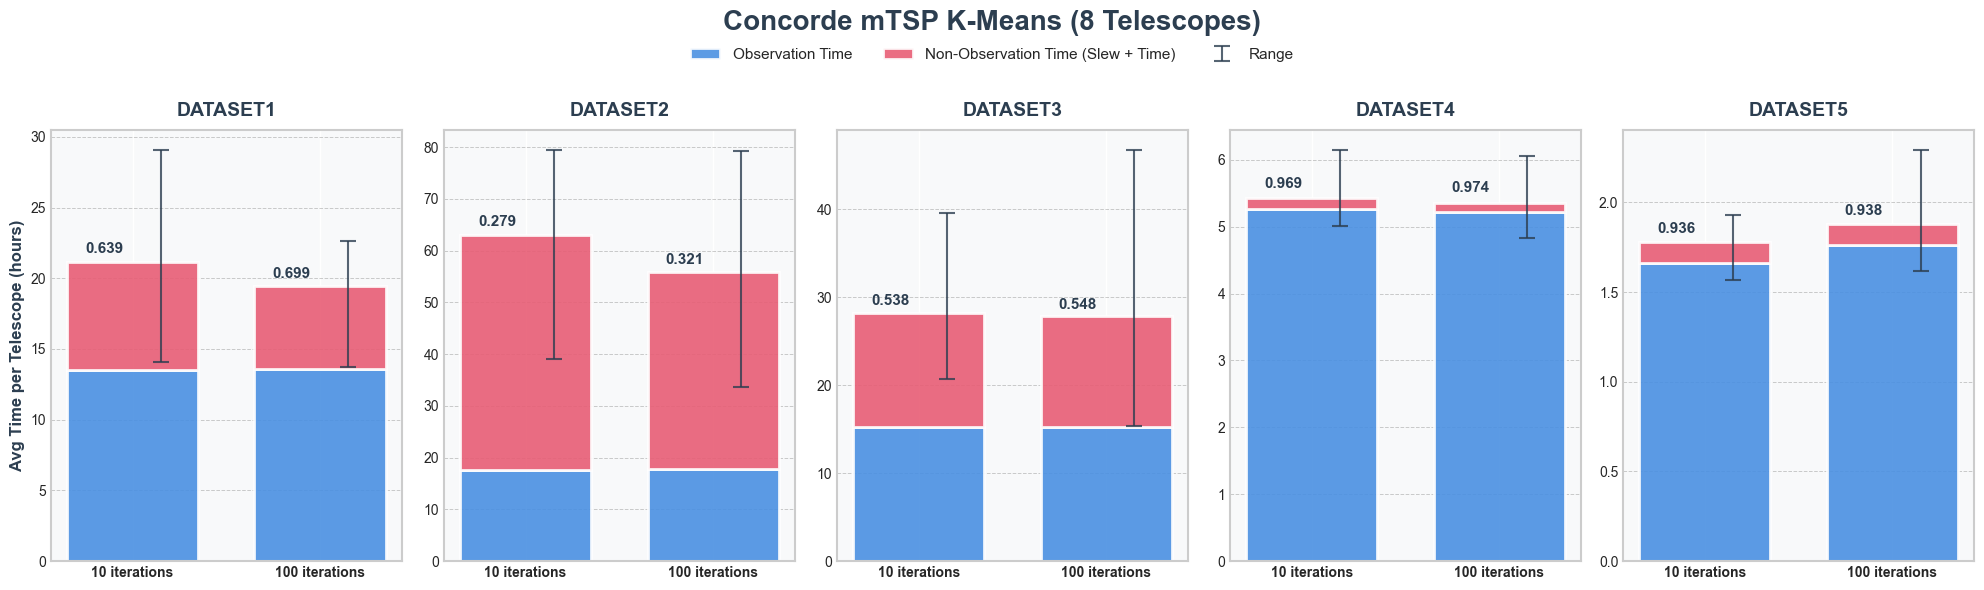

In [61]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Enhanced Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Dataset Configuration
datasets = ['dataset1/', 'dataset2/', 'dataset3/', 'dataset4/', 'dataset5/']
folders = ['tspcKmean8ite10', 'tspcKmean8']
folder_name_map = {
    "tspcKmean8ite10": "10 iterations",
    "tspcKmean8": "100 iterations"
}

# Color palette
colors = {
    'observation': '#4A90E2',
    'non_observation': '#E85D75',
    'error_bar': '#2C3E50'
}

# Data Processing
dataset_dfs = {}

for dataset in datasets:
    dataset_name = os.path.basename(os.path.normpath(dataset)) or dataset.strip('/')
    stats_list = []
    
    for folder in folders:
        folder_path = os.path.join(dataset, folder)
        csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
        raw_folder_name = os.path.basename(os.path.normpath(folder))
        folder_name = folder_name_map.get(raw_folder_name, raw_folder_name)
        
        print(f"Processing {dataset_name} - {folder_name} with {len(csv_files)} files.")
        
        for file in csv_files:
            try:
                df = pd.read_csv(file, header=4)
                df.columns = df.columns.str.strip()
                df['No'] = pd.to_numeric(df['No'], errors='coerce')
                df['Wait time'] = pd.to_numeric(df['Wait time'], errors='coerce')
                
                stats_list.append({
                    'File': os.path.basename(file),
                    'Folder': folder_name,
                    'Total Duration': df['No'].sum() / 4,
                    'Observation Time': df['Wait time'].sum() / 4
                })
            except Exception as e:
                print(f"Error processing {file}: {e}")
    
    dataset_dfs[dataset_name] = pd.DataFrame(stats_list)

# Create unified visualization with subplots
valid_datasets = {k: v for k, v in dataset_dfs.items() if not v.empty}
n_datasets = len(valid_datasets)

if n_datasets == 0:
    print("No valid datasets to display.")
else:
    # Create subplots - 5 datasets in a row
    fig, axes = plt.subplots(1, n_datasets, figsize=(4*n_datasets, 6), dpi=100)
    if n_datasets == 1:
        axes = [axes]
    
    fig.suptitle(f"Concorde mTSP K-Means (8 Telescopes)", 
                 fontsize=20, weight='bold', y=0.98, color='#2C3E50')
    
    for idx, (dataset_name, df) in enumerate(valid_datasets.items()):
        ax = axes[idx]
        
        # Aggregate statistics
        grouped = df.groupby('Folder').agg({
            'Total Duration': ['mean', 'min', 'max'],
            'Observation Time': ['mean', 'min', 'max']
        })
        grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
        summary = grouped.reset_index()
        summary['Non-Observation Time_mean'] = (summary['Total Duration_mean'] - 
                                                summary['Observation Time_mean'])
        
        # Sort by desired order
        desired_order = ["10 iterations", "100 iterations"]
        summary['Folder'] = pd.Categorical(summary['Folder'], categories=desired_order, ordered=True)
        summary = summary.sort_values('Folder')
        
        x = np.arange(len(summary))
        bar_width = 0.7
        
        # Stacked bars
        ax.bar(x, summary['Observation Time_mean'], 
               label='Observation Time' if idx == 0 else '', 
               color=colors['observation'], 
               edgecolor='white', 
               linewidth=2, 
               width=bar_width,
               alpha=0.9)
        
        ax.bar(x, summary['Non-Observation Time_mean'], 
               bottom=summary['Observation Time_mean'],
               label='Non-Observation Time (Slew + Time)' if idx == 0 else '', 
               color=colors['non_observation'], 
               edgecolor='white', 
               linewidth=2, 
               width=bar_width,
               alpha=0.9)
        
        # Error bars
        total_err_lower = summary['Total Duration_mean'] - summary['Total Duration_min']
        total_err_upper = summary['Total Duration_max'] - summary['Total Duration_mean']
        
        ax.errorbar(x + 0.15, summary['Total Duration_mean'], 
                    yerr=[total_err_lower, total_err_upper],
                    fmt='none', 
                    ecolor=colors['error_bar'], 
                    capsize=6, 
                    capthick=1.5, 
                    linewidth=1.5,
                    alpha=0.8,
                    label='Range' if idx == 0 else '')
        
        # Efficiency ratios
        observation_ratio = summary['Observation Time_mean'] / summary['Total Duration_mean']
        for i, (total, ratio) in enumerate(zip(summary['Total Duration_mean'], observation_ratio)):
            ax.text(i - 0.05, total + 0.02 * total,
                    f"{ratio:.3f}",
                    ha='right', va='bottom', 
                    fontsize=11, 
                    weight='bold',
                    color=colors['error_bar'])
        
        # Styling
        ax.set_title(f"{dataset_name.upper()}", fontsize=14, weight='bold', pad=10, color='#2C3E50')
        ax.set_xticks(x)
        ax.set_xticklabels(summary['Folder'], fontsize=10, weight='bold', rotation=0)
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.4, color='gray')
        ax.set_axisbelow(True)
        
        # Y-label only on first subplot
        if idx == 0:
            ax.set_ylabel("Avg Time per Telescope (hours)", fontsize=12, weight='bold', color='#2C3E50')
        
        # Borders
        for spine in ax.spines.values():
            spine.set_edgecolor('#CCCCCC')
            spine.set_linewidth(1.5)
    
    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.94), 
               ncol=3, fontsize=11, framealpha=0.95, edgecolor='gray', 
               fancybox=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()